In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv

# Carica le variabili dal file .env
load_dotenv()

password = quote_plus(os.getenv("DB_PASSWORD"))
user     = os.getenv("DB_USER")
host     = os.getenv("DB_HOST")
db       = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+mysqlconnector://{user}:{password}@{host}/{db}"
)

print("✅ Connessione stabilita")

✅ Connessione stabilita


In [7]:
# ── Analisi metodi di pagamento ──────────────────────────────

query_payments = """
SELECT
    payment_type,
    COUNT(*)                     AS numero_transazioni,
    ROUND(AVG(payment_value), 2) AS valore_medio,
    ROUND(SUM(payment_value), 2) AS valore_totale
FROM order_payments
WHERE payment_type != 'not_defined'
GROUP BY payment_type
ORDER BY valore_totale DESC
"""

df_payments = pd.read_sql(query_payments, engine)
df_payments

,payment_type,numero_transazioni,valore_medio,valore_totale
0,credit_card,76795,163.32,12542084.19
1,boleto,19784,145.03,2869361.27
2,voucher,5775,65.70,379436.87
3,debit_card,1529,142.57,217989.79


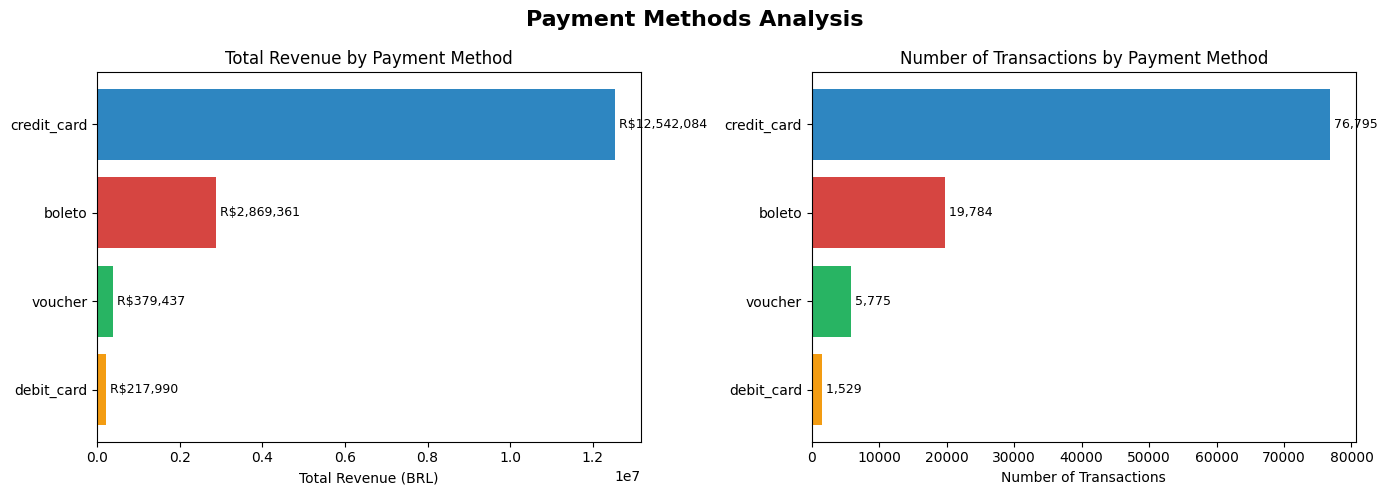

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Payment Methods Analysis", fontsize=16, fontweight="bold")

# ── Grafico 1 — Fatturato totale per metodo ──────────────────
axes[0].barh(
    df_payments["payment_type"],
    df_payments["valore_totale"],
    color=["#2E86C1", "#D64541", "#28B463", "#F39C12"]
)
axes[0].set_title("Total Revenue by Payment Method")
axes[0].set_xlabel("Total Revenue (BRL)")
axes[0].invert_yaxis()

# Aggiunge i valori sulle barre
for i, v in enumerate(df_payments["valore_totale"]):
    axes[0].text(v, i, f" R${v:,.0f}", va="center", fontsize=9)

# ── Grafico 2 — Numero transazioni per metodo ────────────────
axes[1].barh(
    df_payments["payment_type"],
    df_payments["numero_transazioni"],
    color=["#2E86C1", "#D64541", "#28B463", "#F39C12"]
)
axes[1].set_title("Number of Transactions by Payment Method")
axes[1].set_xlabel("Number of Transactions")
axes[1].invert_yaxis()

for i, v in enumerate(df_payments["numero_transazioni"]):
    axes[1].text(v, i, f" {v:,}", va="center", fontsize=9)

plt.tight_layout()
#plt.savefig("output/payments_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── Analisi ritardi di consegna per stato ────────────────────

query_delivery = """
SELECT
    customer_state,
    COUNT(*)                                         AS numero_ordini,
    ROUND(AVG(DATEDIFF(
        order_delivered_customer_date,
        order_estimated_delivery_date)), 1)          AS ritardo_medio_giorni,
    ROUND(AVG(DATEDIFF(
        order_delivered_customer_date,
        order_purchase_timestamp)), 1)               AS giorni_medi_consegna,
    ROUND(100.0 * SUM(CASE
        WHEN order_delivered_customer_date > order_estimated_delivery_date
        THEN 1 ELSE 0 END) / COUNT(*), 1)            AS percentuale_ritardo
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE order_delivered_customer_date IS NOT NULL
GROUP BY customer_state
ORDER BY percentuale_ritardo DESC
"""

df_delivery = pd.read_sql(query_delivery, engine)
df_delivery

,customer_state,numero_ordini,ritardo_medio_giorni,giorni_medi_consegna,percentuale_ritardo
0,AL,397,-8.7,24.5,23.9
1,MA,717,-9.6,21.5,19.7
2,PI,476,-11.3,19.4,16.0
3,CE,1279,-10.8,21.2,15.3
4,SE,335,-10.0,21.5,15.2
5,BA,3256,-10.8,19.3,14.0
6,RJ,12353,-11.8,15.2,13.5
7,TO,274,-12.1,17.6,12.8
8,PA,946,-14.1,23.7,12.4
9,ES,1995,-10.5,15.7,12.2


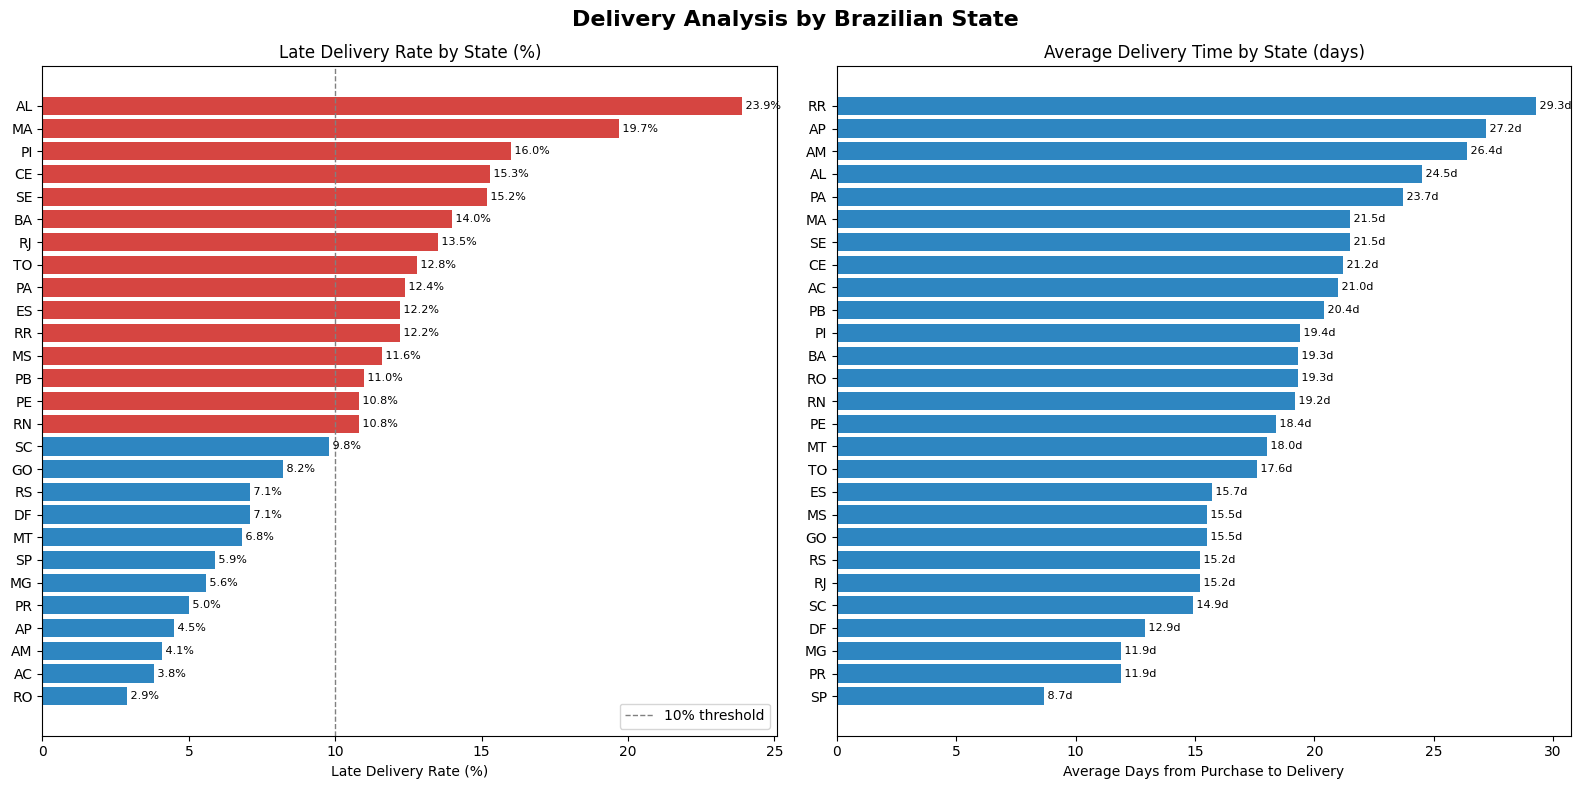

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Delivery Analysis by Brazilian State", fontsize=16, fontweight="bold")

# ── Grafico 1 — Percentuale ritardo per stato ────────────────
df_sorted = df_delivery.sort_values("percentuale_ritardo", ascending=True)

colors = ["#D64541" if x > 10 else "#2E86C1" for x in df_sorted["percentuale_ritardo"]]

axes[0].barh(
    df_sorted["customer_state"],
    df_sorted["percentuale_ritardo"],
    color=colors
)
axes[0].axvline(10, color="gray", linestyle="--", linewidth=1, label="10% threshold")
axes[0].set_title("Late Delivery Rate by State (%)")
axes[0].set_xlabel("Late Delivery Rate (%)")
axes[0].legend()

for i, v in enumerate(df_sorted["percentuale_ritardo"]):
    axes[0].text(v, i, f" {v}%", va="center", fontsize=8)

# ── Grafico 2 — Giorni medi di consegna per stato ────────────
df_sorted2 = df_delivery.sort_values("giorni_medi_consegna", ascending=True)

axes[1].barh(
    df_sorted2["customer_state"],
    df_sorted2["giorni_medi_consegna"],
    color="#2E86C1"
)
axes[1].set_title("Average Delivery Time by State (days)")
axes[1].set_xlabel("Average Days from Purchase to Delivery")

for i, v in enumerate(df_sorted2["giorni_medi_consegna"]):
    axes[1].text(v, i, f" {v}d", va="center", fontsize=8)

plt.tight_layout()
#plt.savefig("output/delivery_analysis.png", dpi=150, bbox_inches="tight")
plt.show()